# Impute and smooth trajectories

We smooth outtrajectories with `magic-impute` and then make spline curves of each gene. We need `magic` installed with
```
pip install magic-impute # bash
```

In [1]:
%run ../Script/analysisLibraries

In [2]:
%run ../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
adata = sc.read('./write/adata.dpt.h5ad')

Subset cells and nuclei and impute raw counts

In [6]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

In [7]:
names = pd.Series(NUCLEI.var_names, index=NUCLEI.var_names)
oldnames = ['KEF41-p01','KEF41-p02','KEF41-p03','KEF41-p04','KEF41-p05','KEF41-p06',
       'KEF41-p07','KEF41-p08','KEF41-p09','KEF41-p10','KEF41-p11','KEF41-p12',
       'KEF41-p13']
inters = np.intersect1d(NUCLEI.var_names, oldnames)
newnames = ['CYTB','ND6','ND5','ND4','ND4L','ND3','COX3','ATP6','ATP8','COX2','COX1','ND2','ND1']

if len(inters)>0:
       names[inters] = newnames[oldnames.index(inters)]
       NUCLEI.var_names = np.array(names)
       print(inters)

In [8]:
names = pd.Series(CELLS.var_names, index=CELLS.var_names)
oldnames = ['KEF41-p01','KEF41-p02','KEF41-p03','KEF41-p04','KEF41-p05','KEF41-p06',
       'KEF41-p07','KEF41-p08','KEF41-p09','KEF41-p10','KEF41-p11','KEF41-p12',
       'KEF41-p13']
inters = np.intersect1d(CELLS.var_names, oldnames)
newnames = ['CYTB','ND6','ND5','ND4','ND4L','ND3','COX3','ATP6','ATP8','COX2','COX1','ND2','ND1']

if len(inters)>0:
       names[inters] = newnames[oldnames.index(inters)]
       CELLS.var_names = np.array(names)
       print(inters)

In [9]:
NUCLEI.layers["raw_counts"] = np.array(NUCLEI.layers["raw_counts"].todense())

In [10]:
CELLS.layers["raw_counts"] = np.array(CELLS.layers["raw_counts"].todense())

In [11]:
import magic

In [12]:
magic_op = magic.MAGIC()

imputation

In [13]:
CELLS_magic = magic_op.fit_transform( np.array(CELLS.layers['correct_counts'].todense()) )

Calculating MAGIC...
  Running MAGIC on 2676 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 2.21 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.40 seconds.
    Calculating affinities...
    Calculated affinities in 0.41 seconds.
  Calculated graph and diffusion operator in 3.02 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 0.33 seconds.
Calculated MAGIC in 3.38 seconds.


In [14]:
CELLS.layers['MAGIC_counts'] = CELLS_magic.copy()

In [15]:
NUCLEI_magic = magic_op.fit_transform( np.array(NUCLEI.layers['correct_counts'].todense()) )

Calculating MAGIC...
  Running MAGIC on 7280 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 6.08 seconds.
    Calculating KNN search...
    Calculated KNN search in 2.67 seconds.
    Calculating affinities...
    Calculated affinities in 2.65 seconds.
  Calculated graph and diffusion operator in 11.41 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 2.08 seconds.
Calculated MAGIC in 13.55 seconds.


In [16]:
NUCLEI.layers['MAGIC_counts'] = NUCLEI_magic.copy()

Put together the two imputations in the original object

In [17]:
adata.layers['MAGIC_counts'] = adata.X.copy()
adata[ adata.obs['batch']=='Cells', :].layers['MAGIC_counts'] = CELLS.layers['MAGIC_counts']
adata[ adata.obs['batch']=='Nuclei', :].layers['MAGIC_counts'] = NUCLEI.layers['MAGIC_counts']

In [18]:
adata.X = adata.layers['MAGIC_counts'].copy()

Create some dataframes to put together all the things we need

In [19]:
df_cell = pd.DataFrame(adata[adata.obs['batch']=='Cells'].X,
                 index=adata[adata.obs['batch']=='Cells'].obs_names,
                 columns=adata[adata.obs['batch']=='Cells'].var_names)
df_nuc = pd.DataFrame(adata[adata.obs['batch']=='Nuclei'].X,
                 index=adata[adata.obs['batch']=='Nuclei'].obs_names,
                 columns=adata[adata.obs['batch']=='Nuclei'].var_names)

In [20]:
df_cell['pseudotimes'] = adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign'].copy()
df_cell['cluster'] = adata[adata.obs['batch']=='Cells'].obs['clusters_single'].copy()
df_cell['cells_nuclei'] = adata[adata.obs['batch']=='Cells'].obs['batch'].copy()

In [21]:
df_nuc['pseudotimes'] = adata[adata.obs['batch']=='Nuclei'].obs['dpt_cellalign'].copy()
df_nuc['cluster'] = adata[adata.obs['batch']=='Nuclei'].obs['clusters_single'].copy()
df_nuc['cells_nuclei'] = adata[adata.obs['batch']=='Nuclei'].obs['batch'].copy()

In [22]:
df = pd.DataFrame(adata.layers["raw_counts"].todense(),
                 index=adata.obs_names,
                 columns=adata.var_names)

In [23]:
df['pseudotimes'] = adata.obs['dpt_cellalign'].copy()
df['cluster'] = adata.obs['clusters_single'].copy()
df['cells_nuclei'] = adata.obs['batch'].copy()

Function to plot a trajectory from either cells or nuclei

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1000x400 with 0 Axes>

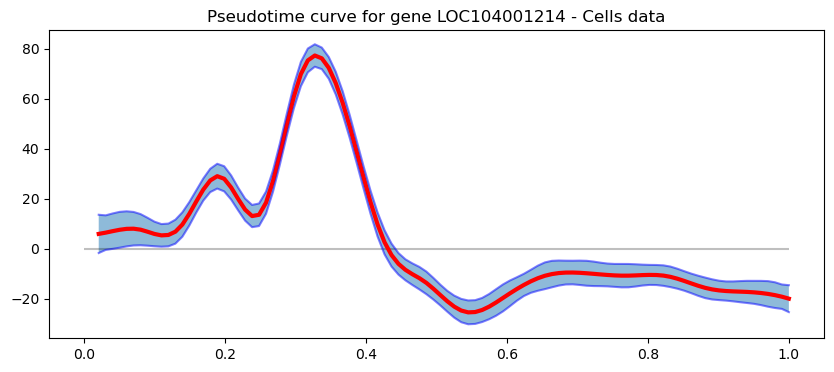

In [24]:
plot_genes_single(CELLS, GENE='LOC104001214', dataset_name='Cells')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1000x400 with 0 Axes>

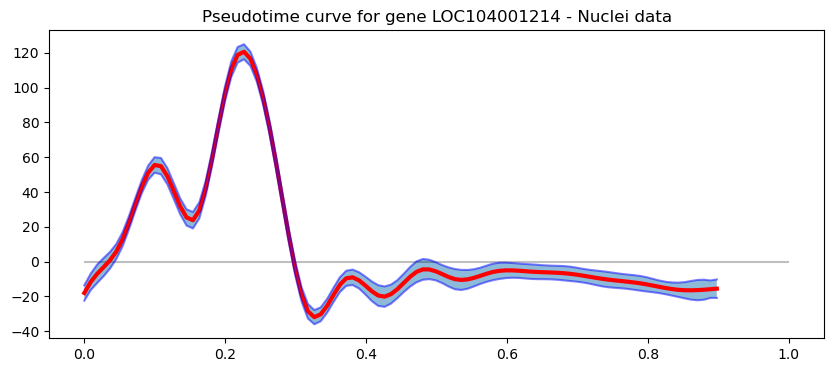

In [25]:
plot_genes_single(NUCLEI, GENE='LOC104001214', dataset_name='Nuclei')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1000x400 with 0 Axes>

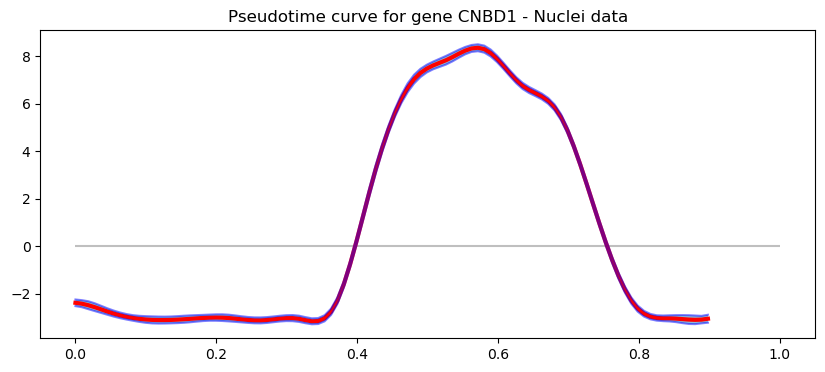

In [24]:
plot_genes_single(NUCLEI, GENE='CNBD1', dataset_name='Nuclei')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1000x400 with 0 Axes>

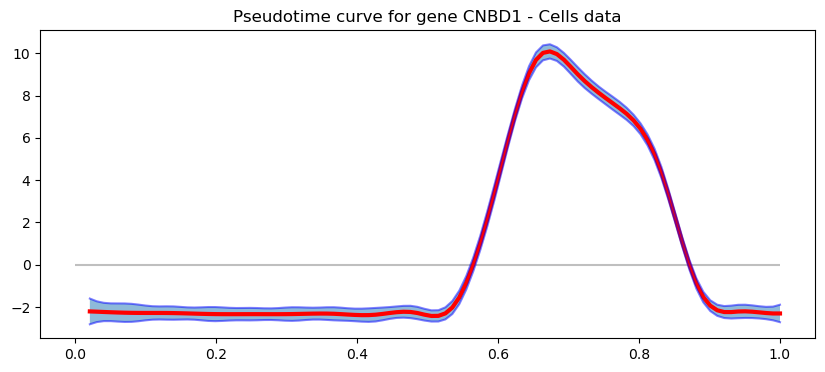

In [26]:
plot_genes_single(CELLS, GENE='CNBD1', dataset_name='Cells')

function to plot side by side with the style as above

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x400 with 0 Axes>

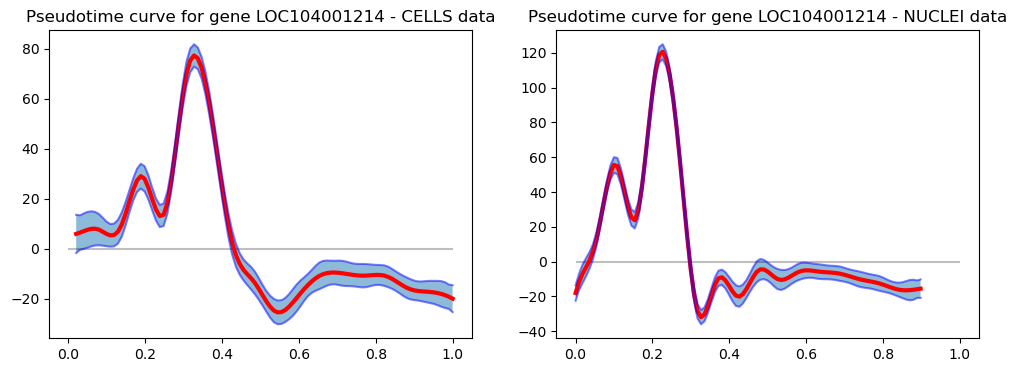

In [26]:
plot_genes_sidebyside(CELLS, NUCLEI, GENE='LOC104001214')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x400 with 0 Axes>

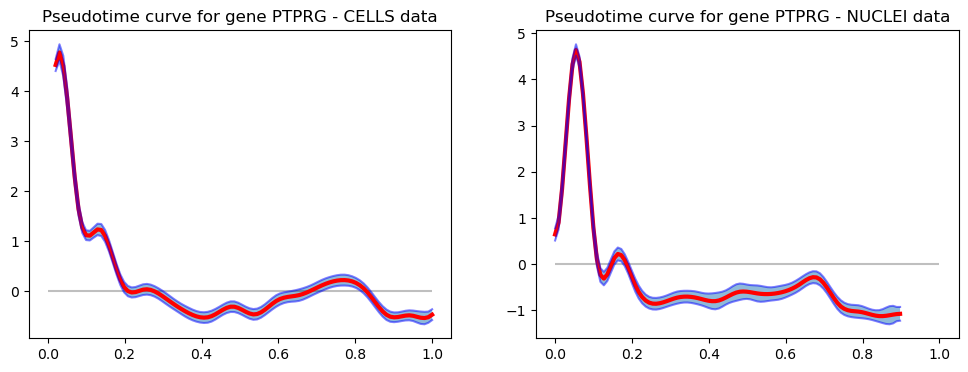

In [27]:
plot_genes_sidebyside(CELLS, NUCLEI, GENE='PTPRG')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x400 with 0 Axes>

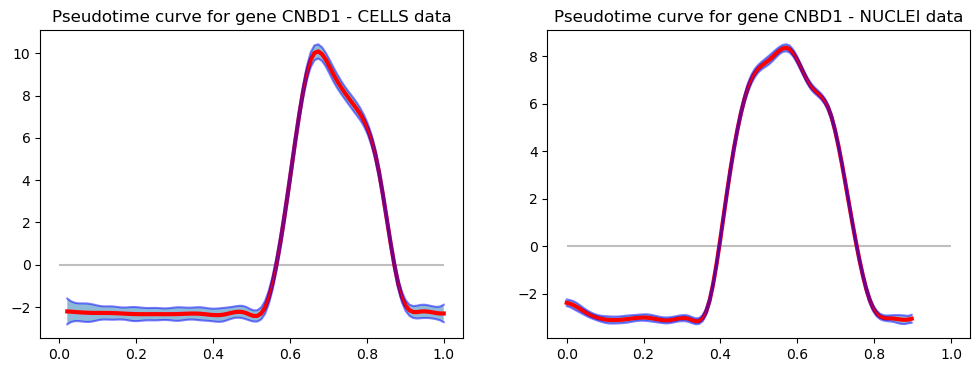

In [27]:
plot_genes_sidebyside(CELLS, NUCLEI, GENE='CNBD1')

Plot genes overlapping in the same plot. I commented out the standardization, but can be done or in alternative one can do scaling from 0 to 1

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x800 with 0 Axes>

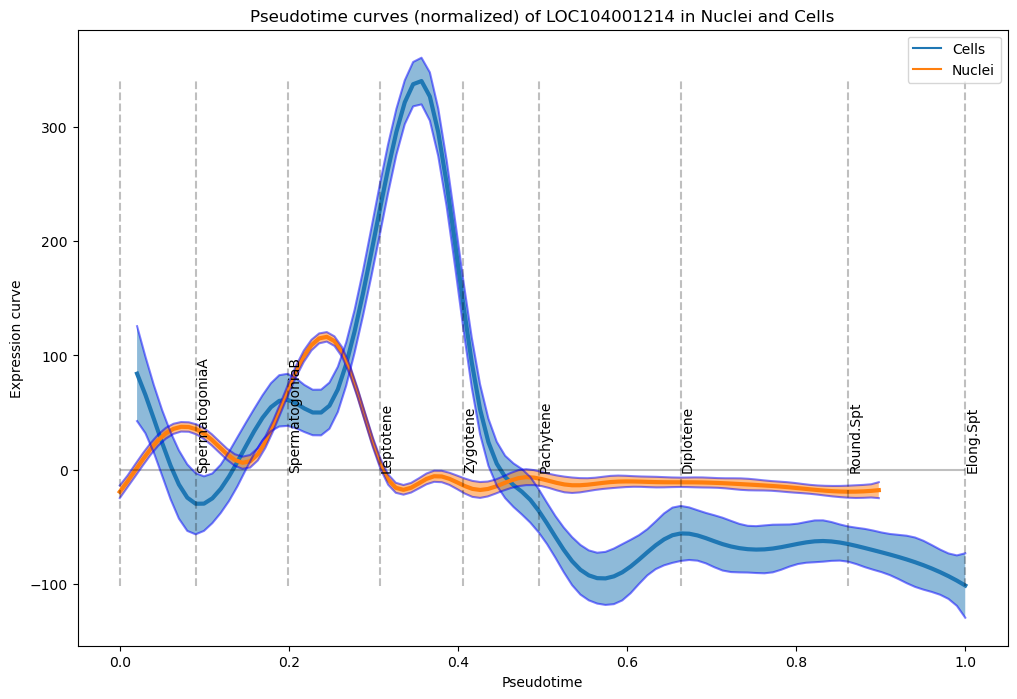

In [28]:
plot_genes_overlap(CELLS,
                   NUCLEI, 
                   N_grid=100, 
                   GENE='LOC104001214', 
                   layer="raw_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x800 with 0 Axes>

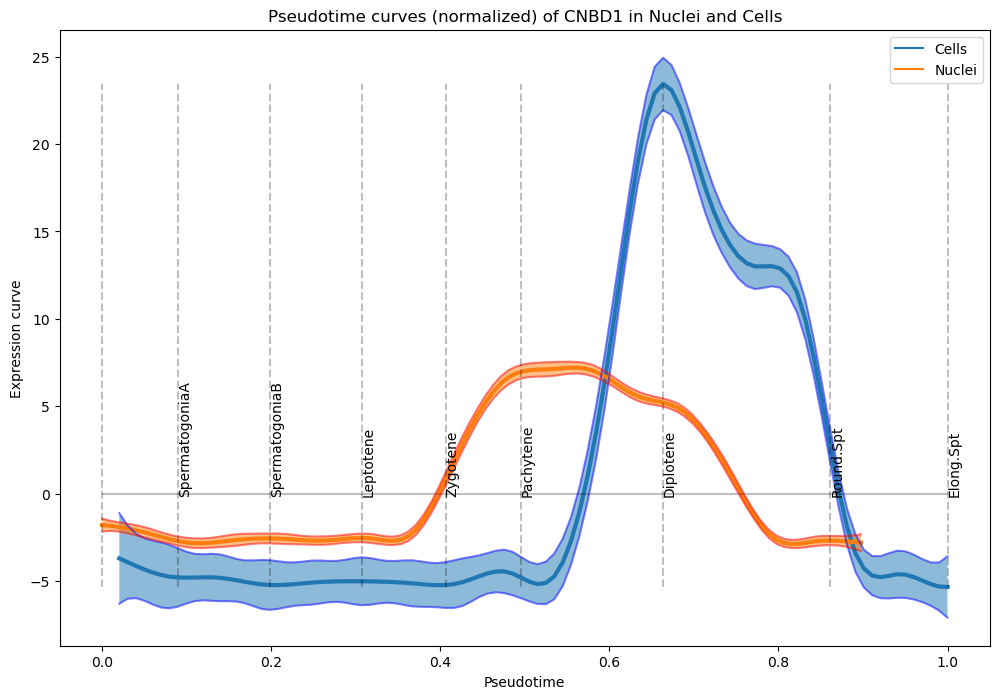

In [28]:
plot_genes_overlap(CELLS,
                   NUCLEI, 
                   N_grid=100, 
                   GENE='CNBD1', 
                   layer="raw_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x800 with 0 Axes>

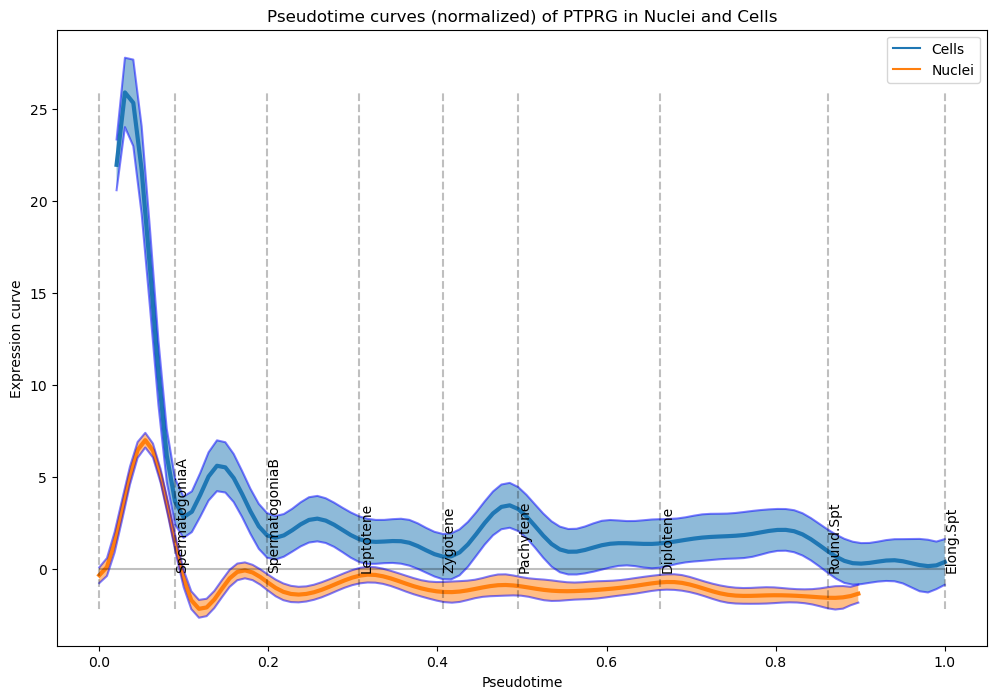

In [ ]:
plot_genes_overlap(CELLS,
                   NUCLEI, 
                   N_grid=100, 
                   GENE='PTPRG', 
                   layer="raw_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x800 with 0 Axes>

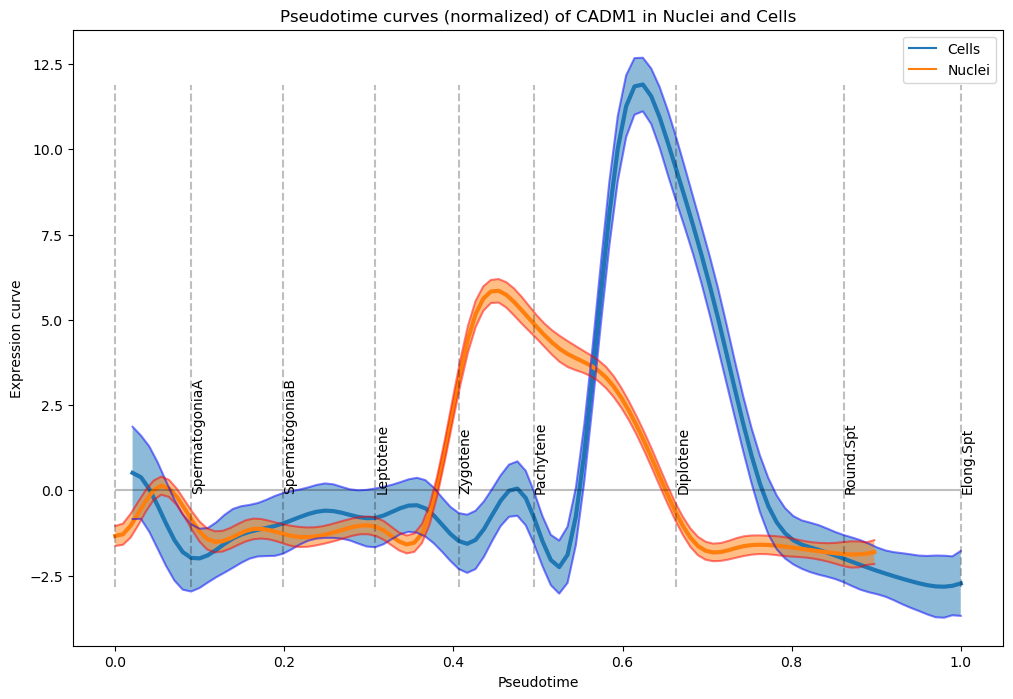

In [29]:
plot_genes_overlap(CELLS,
                   NUCLEI, 
                   N_grid=100, 
                   GENE='CADM1', 
                   layer="raw_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


<Figure size 1200x800 with 0 Axes>

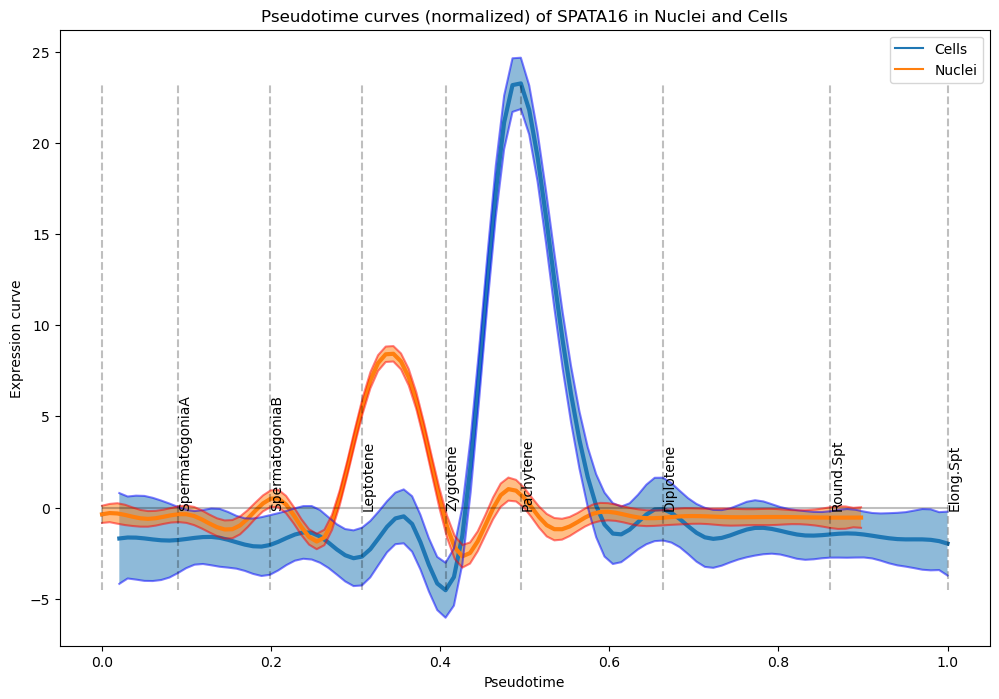

In [30]:
plot_genes_overlap(CELLS,
                   NUCLEI, 
                   N_grid=100, 
                   GENE='SPATA16', 
                   layer="raw_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

same code as above but pulls out times and coordinates of the gene trajectory if needed for comparison

In [40]:
y_cell, y_nuc, x_cell, x_nuc = calc_genes_overlap(CELLS, 
                   NUCLEI, 
                   N_grid=100, 
                   GENE='LOC104001214', 
                   layer="MAGIC_counts", 
                   plot_size=(12,8), 
                   cluster_key='clusters_single')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


# Create heatmap with aligned pseudotimes

plot n_genes in heatmaps side by side for a specific cluster, keep only genes with thresholds of distance of the peaks from the trajectories above (D_th) and low correlation (T_th threshold).

In [41]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

In [42]:
CELLS.X = CELLS.layers['raw_counts'].copy()
NUCLEI.X = NUCLEI.layers['raw_counts'].copy()

In [37]:
#sc.pp.subsample(NUCLEI, n_obs=CELLS.shape[0], random_state=123)

subsampling counts in each cell

In [43]:
NUCLEI_S = sc.pp.downsample_counts(NUCLEI, counts_per_cell=int(np.mean(CELLS.obs['total_counts'])), copy=True, random_state=123)
CELLS_S = sc.pp.downsample_counts(CELLS, counts_per_cell=int(np.mean(NUCLEI.obs['total_counts'])), copy=True, random_state=123)

In [44]:
sc.pp.log1p(NUCLEI_S)
sc.pp.log1p(CELLS_S)

In [45]:
adata_S = adata[ np.concatenate( (CELLS_S.obs_names, NUCLEI_S.obs_names) ) ].copy()

/faststorage/project/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [46]:
adata_S.layers['downsampled_counts'] = adata_S.X.copy()
adata_S[ adata_S.obs['batch']=='Cells', :].layers['downsampled_counts'] = CELLS_S.X
adata_S[ adata_S.obs['batch']=='Nuclei', :].layers['downsampled_counts'] = NUCLEI_S.X

In [34]:
def delay_heatmap(adata, 
                  NUCLEI, 
                  CELLS, 
                  D_th=.2, 
                  T_th=.5, 
                  geneNames=['AKAP4','PRM1','PRM2','TNP1','TNP2'], 
                  vmin=0, 
                  vmax=3, 
                  cluster="SpermatogoniaA", 
                  cluster_key="clusters_compact",
                 ):

    
    geneNames = np.intersect1d( geneNames, adata.var_names )
    geneNames = np.intersect1d( geneNames, NUCLEI.var_names )
    geneNames = np.intersect1d( geneNames, CELLS.var_names )
    print("remaining genes after intersecting with data:", geneNames)

    adata.X = adata.layers["raw_counts"].copy()
    sc.pp.log1p(adata)
    
    #sc.tl.rank_genes_groups(adata, groupby=cluster_key, n_genes=n_genes)
    #result = adata.uns['rank_genes_groups']
    #groups = result['names'].dtype.names
    #X = pd.DataFrame(
    #{group + '_' + key[:1].upper(): result[key][group]
    #for group in groups for key in ['names', 'pvals_adj','logfoldchanges']})

    #genes=np.ravel(np.array(X[ [f'{cluster}_N'] ]))

    dpt = adata.obs['dpt_cellalign']
    D = pd.Series(index=geneNames)
    T = pd.Series(index=geneNames)

    for V in geneNames:
        C, N, Ct, Nt = calc_genes_overlap(CELLS, NUCLEI, GENE=V, cluster_key=cluster_key)
        D[V] = Ct[np.argmax(C)] - Nt[np.argmax(N)]
        T[V] = np.cov(C,N)[0,1]

    adata.X = adata.layers["SCT_counts"]
    genes = D[(D>D_th)&(T<T_th)].index

    obs_name='dpt_cellalign'
    adata_left=NUCLEI
    adata_right=CELLS
    sc.pp.scale(CELLS)
    sc.pp.scale(NUCLEI)

    
    
    dpt_left = np.sort( np.unique( adata_left.obs[obs_name] ) )
    dpt_left = dpt_left[dpt_left>=0]
    dpt_right = np.sort( np.unique( adata_right.obs[obs_name] ) )
    dpt_right = dpt_right[dpt_right>=0]
    dpt = [np.mean([i,j]) for i,j in zip (dpt_left,dpt_right)]

    print(len(dpt_left), len(dpt_right), len(dpt))
    print(dpt_left)
    print(dpt_right)
    print(dpt)
    
    df_left = pd.DataFrame(index=geneNames, columns=dpt_left, dtype='float16')
    df_right = pd.DataFrame(index=geneNames, columns=dpt_right, dtype='float16')

    for G in geneNames:
        gene_data = adata_left[:,G].X
        for T in dpt_left:
            df_left.loc[G,T] = np.max(gene_data[ adata_left.obs[obs_name]==T ])

    for G in geneNames:
        gene_data = adata_right[:,G].X
        for T in dpt_right:
            df_right.loc[G,T] = np.max(gene_data[ adata_right.obs[obs_name]==T ])

    df_left.columns = dpt_left
    df_right.columns = dpt_right


    tmp = [ (i,j) for i,j in zip( np.hstack([np.repeat(['NUCLEI'], len(dpt_left)),np.repeat(['CELLS'], len(dpt_right))]), 
       np.hstack([dpt_left, dpt_right]) )]
    index = pd.MultiIndex.from_tuples(tmp)

    df_all = pd.DataFrame( np.vstack([df_left.T,df_right.T]), index=index ).T
    df_all[df_all<vmin]=vmin
    df_all[df_all>vmax]=vmax

    # Define a weighting scheme (e.g., linear or exponential)
    #weights_l = np.linspace(1, 0, len(dpt_left))
    #weights_r = np.linspace(1, 0, len(dpt_right))

    # Calculate scores for each vector
    #scores = [np.sum(df_left.loc[V,:] * weights_l) for V in df_left.index]

    # Use argsort to get the sorted indexes
    #sorted_indexes = np.argsort(scores)[::-1]  # [::-1] to sort in descending order

    # Sort the vectors based on the sorted indexes
    #new_indexes = df_left.index[sorted_indexes]
    #df_left2 = df_left.loc[new_indexes,:]
    #df_right2 = df_right.loc[new_indexes,:]

    df_all2 = pd.DataFrame( np.vstack([df_left.T,df_right.T]), index=index ).T
    df_all[df_all<vmin]=vmin
    df_all[df_all>vmax]=vmax

    import matplotlib.colors as mcolors

    # Create column colors: first 50 blue, next 50 red
    col_colors = ['blue'] * 50 + ['red'] * 50
    col_colors = col_colors[:len(df_all.columns)]  # Ensure it matches the number of columns

    f=sns.clustermap(df_all, col_cluster=False, row_cluster=False, 
                 xticklabels='', yticklabels='', figsize=(10, 20), 
                 cbar_pos=(0,0.5,.1,.2), cbar_kws={'label':'Expression'},
                 cmap='Blues', col_colors=col_colors)
    ax = f.ax_heatmap  # this is the important part
    ax.plot([50, 50], [0, len(genes)], 'k-', lw = 2)
    ax.axes.set_title(f'Nuclei-Cells comparison of Pseudotime expression for {cluster} cells\n\n')
    ax.axes.set_xlabel("NUCLEI        CELLS")
    ax.axes.set_yticks(np.arange(len(geneNames))+.5)
    ax.axes.set_yticklabels(geneNames)
    #plt.show()
    plt.savefig(f'./{cluster}.png', bbox_inches='tight' )

Print a heatmap for each cluster of the data. It will also be saved as a png file.

/faststorage/project/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:1068: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if isinstance(groupby, str) and is_categorical_dtype(adata.obs[groupby]):


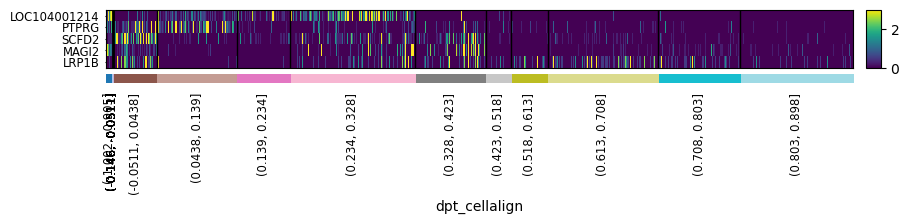

/faststorage/project/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:1068: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if isinstance(groupby, str) and is_categorical_dtype(adata.obs[groupby]):


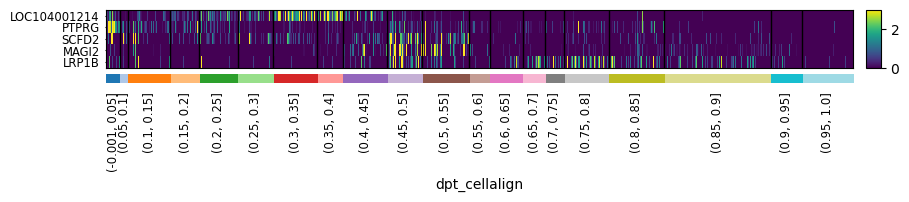

In [ ]:
# Select genes to plot
genes_to_plot = ['LOC104001214', 'PTPRG', 'SCFD2', 'MAGI2', 'LRP1B']

sc.pl.heatmap(NUCLEI, genes_to_plot, num_categories=20, groupby='dpt_cellalign', swap_axes=True, vmax=3, vmin=0)
sc.pl.heatmap(CELLS, genes_to_plot, num_categories=20, groupby='dpt_cellalign', swap_axes=True, vmax=3, vmin=0)


remaining genes after intersecting with data: ['CTNNA3' 'GRIP1' 'HS3ST4' 'LOC104001214' 'LRP1B' 'MAGI2' 'PRKG1' 'PTPRG'
 'SCFD2']


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:  00:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:  00:00:00
 72% (8 of 11) |##################      

50 49 49
[6.28425029e-19 1.82764634e-02 3.66303198e-02 5.50107547e-02
 7.34675909e-02 9.16034984e-02 1.09996721e-01 1.28401335e-01
 1.45743847e-01 1.65043347e-01 1.82982737e-01 2.01509837e-01
 2.19618963e-01 2.38112969e-01 2.56516277e-01 2.74846145e-01
 2.93195263e-01 3.11389256e-01 3.29773256e-01 3.48048742e-01
 3.66262525e-01 3.84762532e-01 4.02494337e-01 4.21054672e-01
 4.39440102e-01 4.57903556e-01 4.76689020e-01 4.94031291e-01
 5.13010969e-01 5.31233778e-01 5.49300763e-01 5.67961702e-01
 5.86439940e-01 6.04586348e-01 6.22914645e-01 6.41213476e-01
 6.59461633e-01 6.77849472e-01 6.96181857e-01 7.14764950e-01
 7.33063477e-01 7.51186723e-01 7.69697393e-01 7.87822281e-01
 8.06119583e-01 8.24500866e-01 8.42789855e-01 8.61837336e-01
 8.79055873e-01 8.97742045e-01]
[0.02043302 0.04037449 0.05911735 0.08260875 0.10227915 0.12258211
 0.14342776 0.16311572 0.18352834 0.20389601 0.22429797 0.24474432
 0.26521657 0.28579994 0.30655969 0.32653538 0.34702338 0.36732315
 0.38822366 0.40802914 0.4

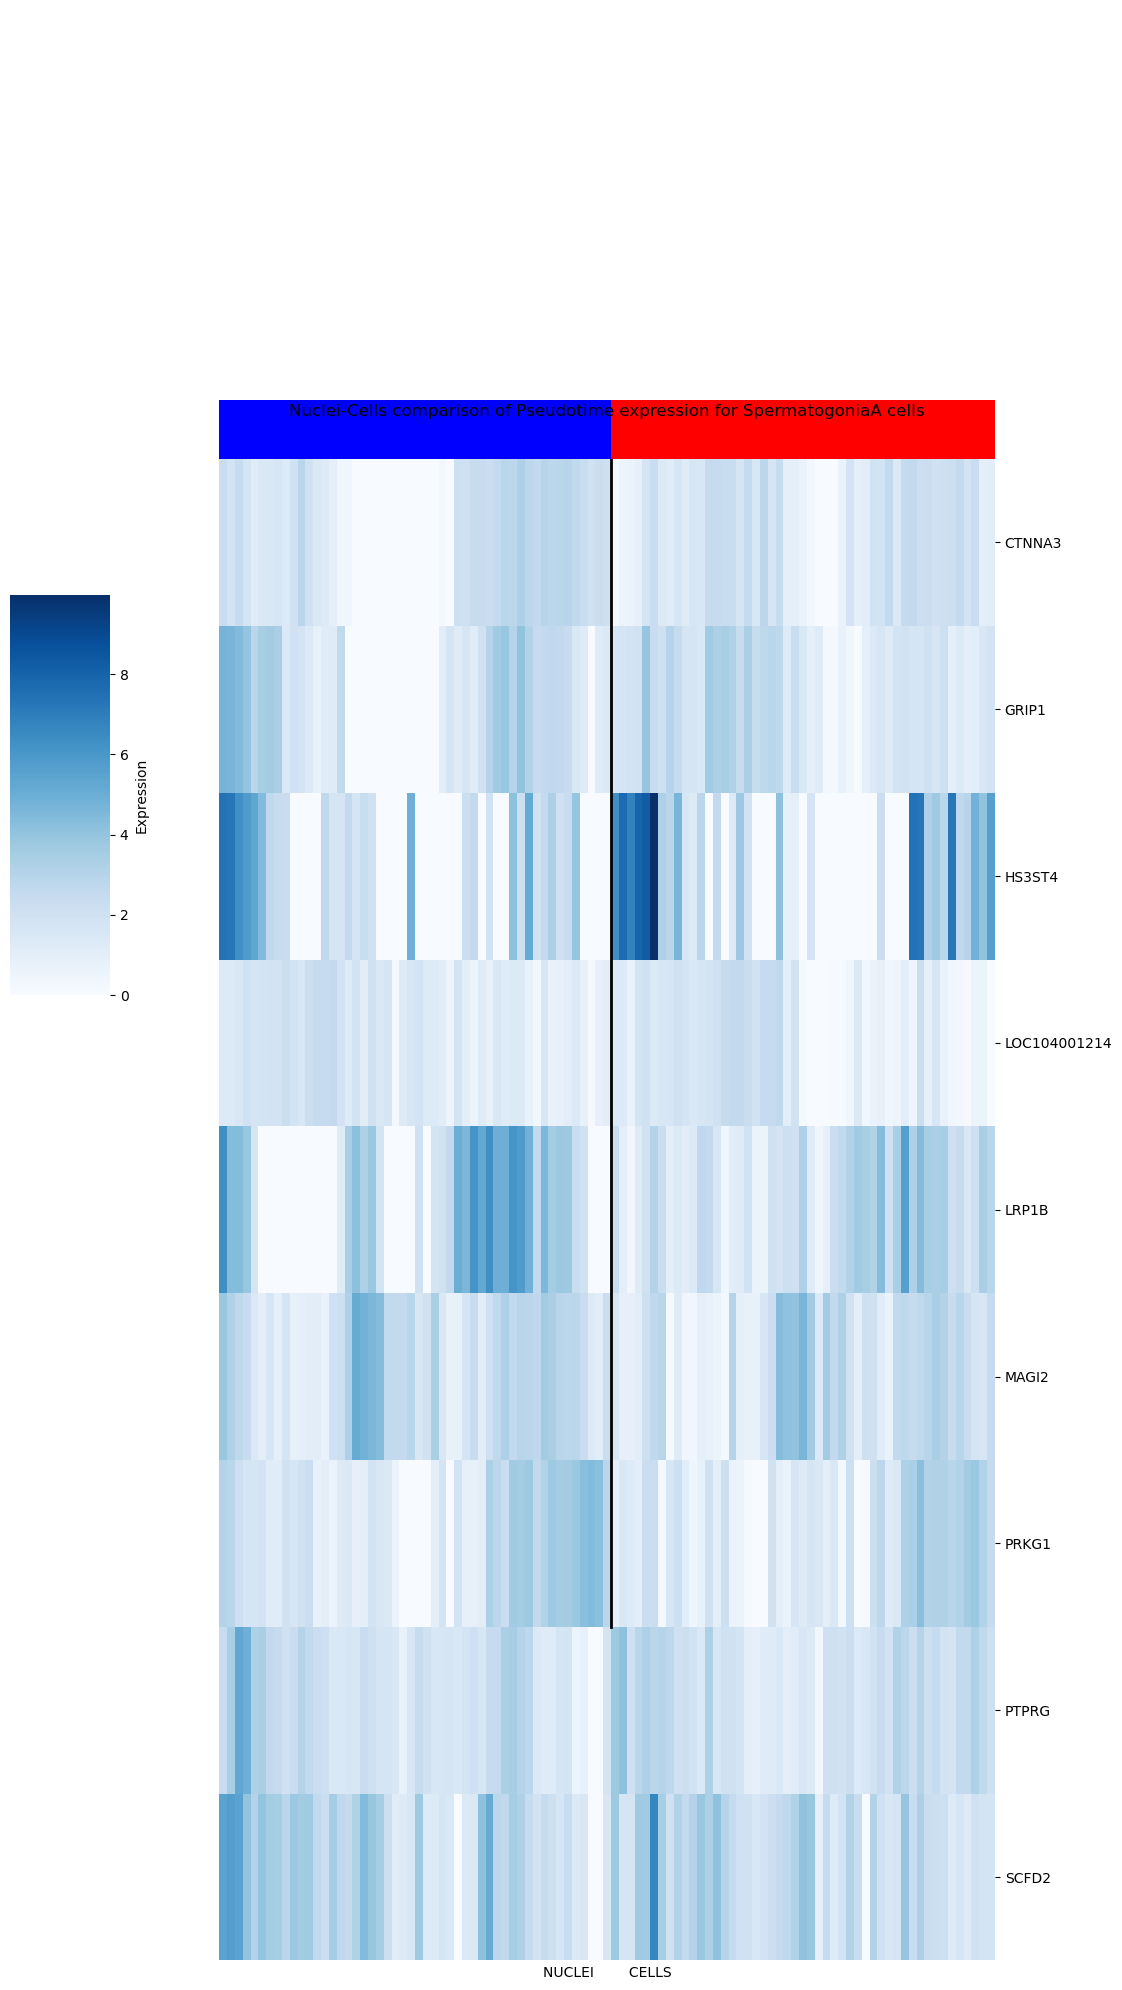

In [36]:
delay_heatmap(adata=adata, NUCLEI=NUCLEI, CELLS=CELLS, 
              D_th=0, T_th=1,
              geneNames=['LOC104001214','PTPRG','SCFD2','MAGI2','LRP1B','GRIP1','HS3ST4','CTNNA3','PRKG1'], 
              vmin=0, vmax=10, 
              cluster='SpermatogoniaA', 
              cluster_key="clusters_compact",
              
              )

Function that prints genes from a list, save as png file

In [102]:
def delay_heatmap_from_list(adata, 
                            nuclei, 
                            cells, 
                            D_th=.2, 
                            T_th=.5, 
                            filter=False, #apply the filtering options or not
                            genes=['TNP1','TNP2'], 
                            vmin=0, vmax=3, 
                            outname='heatmap_from_genes'):
   
    genes=np.intersect1d(genes, adata[:,adata.var['highly_variable']].var_names)
    dpt = adata.obs['dpt_cellalign']
    D = pd.Series(index=genes)
    T = pd.Series(index=genes)

    adata.X = adata.layers["SCT_counts"]

    obs_name='dpt_cellalign'
    adata_left=NUCLEI
    adata_right=CELLS

    dpt_left = np.sort( np.unique( adata_left.obs[obs_name] ) )
    dpt_right = np.sort( np.unique( adata_right.obs[obs_name] ) )
    dpt = [np.mean([i,j]) for i,j in zip (dpt_left,dpt_right)]
    df_left = pd.DataFrame(index=genes, columns=dpt_left, dtype='float16')
    df_right = pd.DataFrame(index=genes, columns=dpt_right, dtype='float16')


    for T in dpt_left:
        subdata = adata_left[adata_left.obs[obs_name]==T, :]
        df_left.loc[:,T] = np.ravel(np.max(subdata[:, genes].X.todense(), axis=0))

    for T in dpt_right:
        subdata = adata_right[adata_right.obs[obs_name]==T, :]
        df_right.loc[:,T] = np.ravel(np.max(subdata[:, genes].X.todense(), axis=0))
        
    if(filter):
        print("length of genes before filter:",len(genes))
        D = pd.Series(index=genes)
        T = pd.Series(index=genes)
        Ct = df_right.columns
        Nt = df_left.columns
        for V in genes:
            C = df_right.loc[V,:]
            N = df_left.loc[V,:]
            D[V] = Ct[np.argmax(C)] - Nt[np.argmax(N)]
            T[V] = np.cov(C,N)[0,1]
        genes = D[(D>D_th)&(T<T_th)].index
        print("length of genes after filter:",len(genes))
    
    df_left.columns=dpt
    df_right.columns=dpt
    df_left = df_left.loc[genes,:]
    df_right = df_right.loc[genes,:]

    tmp = [ (i,j) for i,j in zip( np.hstack([np.repeat(['NUCLEI'], 50),np.repeat(['CELLS'], 50)]), 
       np.hstack([dpt, dpt]) )]
    index = pd.MultiIndex.from_tuples(tmp)

    df_all = pd.DataFrame( np.vstack([df_left.T,df_right.T]), index=index ).T
    df_all[df_all<vmin]=vmin
    df_all[df_all>vmax]=vmax

    # Define a weighting scheme (e.g., linear or exponential)
    weights = np.linspace(1, 0, 50)

    # Calculate scores for each vector
    scores = [np.sum(df_left.loc[V,:] * weights) for V in df_left.index]

    # Use argsort to get the sorted indexes - sorting is just to make the heatmap ordering nice
    sorted_indexes = np.argsort(scores)[::-1]  # [::-1] to sort in descending order

    # Sort the vectors based on the sorted indexes
    new_indexes = df_left.index[sorted_indexes]
    df_left2 = df_left.loc[new_indexes,:]
    df_right2 = df_right.loc[new_indexes,:]

    df_all2 = pd.DataFrame( np.vstack([df_left2.T,df_right2.T]), index=index, columns=new_indexes ).T
    df_all2[df_all2<vmin]=vmin
    df_all2[df_all2>vmax]=vmax

    plt.rcParams['figure.figsize'] = (8,6)

    f=sns.clustermap(df_all2, col_cluster=False, row_cluster=False, 
                 xticklabels='', yticklabels='', figsize=(10, 50), 
                 cbar_pos=(0,0.5,.1,.2), cbar_kws={'label':'Expression'})
    ax = f.ax_heatmap  # this is the important part
    ax.plot([50, 50], [0, len(genes)], 'k-', lw = 2)
    ax.axes.set_title(f'Nuclei-Cells comparison of Pseudotime expression\n\n')
    ax.axes.set_xlabel("NUCLEI        CELLS")
    ax.axes.set_yticks(np.arange(len(genes))+.5)
    ax.axes.set_yticklabels(new_indexes)
    #plt.show()
    plt.savefig(f'./{outname}.png', bbox_inches='tight' )

In [81]:
#genes = pd.read_csv('./Meikar2014_CBgenes.csv', sep=';')['symbol']

In [82]:
#genes = [G.upper() for G in genes]

In [116]:
genes = np.array( ['KEF41-p11','KEF41-p10','KEF41-p07','CLU','TNP1','PRM2'] )

In [104]:
NUCLEI_S.X = NUCLEI_S.X.todense()

AttributeError: 'numpy.ndarray' object has no attribute 'todense'

In [105]:
CELLS_S.X = CELLS_S.X.todense()

AttributeError: 'numpy.ndarray' object has no attribute 'todense'

In [114]:
CELLS_S.X = np.array(CELLS_S.X)
NUCLEI_S.X = np.array(NUCLEI_S.X)
adata_S.X = np.array(adata_S.layers['downsampled_counts'].copy())

ValueError: Data matrix has wrong shape (), need to be (2337, 23768).

/scratch/26186810/ipykernel_2889324/999144892.py:31: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_left.loc[:,T] = np.ravel(np.max(subdata[:, genes].X.todense(), axis=0))
/scratch/26186810/ipykernel_2889324/999144892.py:31: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_left.loc[:,T] = np.ravel(np.max(subdata[:, genes].X.todense(), axis=0))
/scratch/26186810/ipykernel_2889324/999144892.py:31: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. 

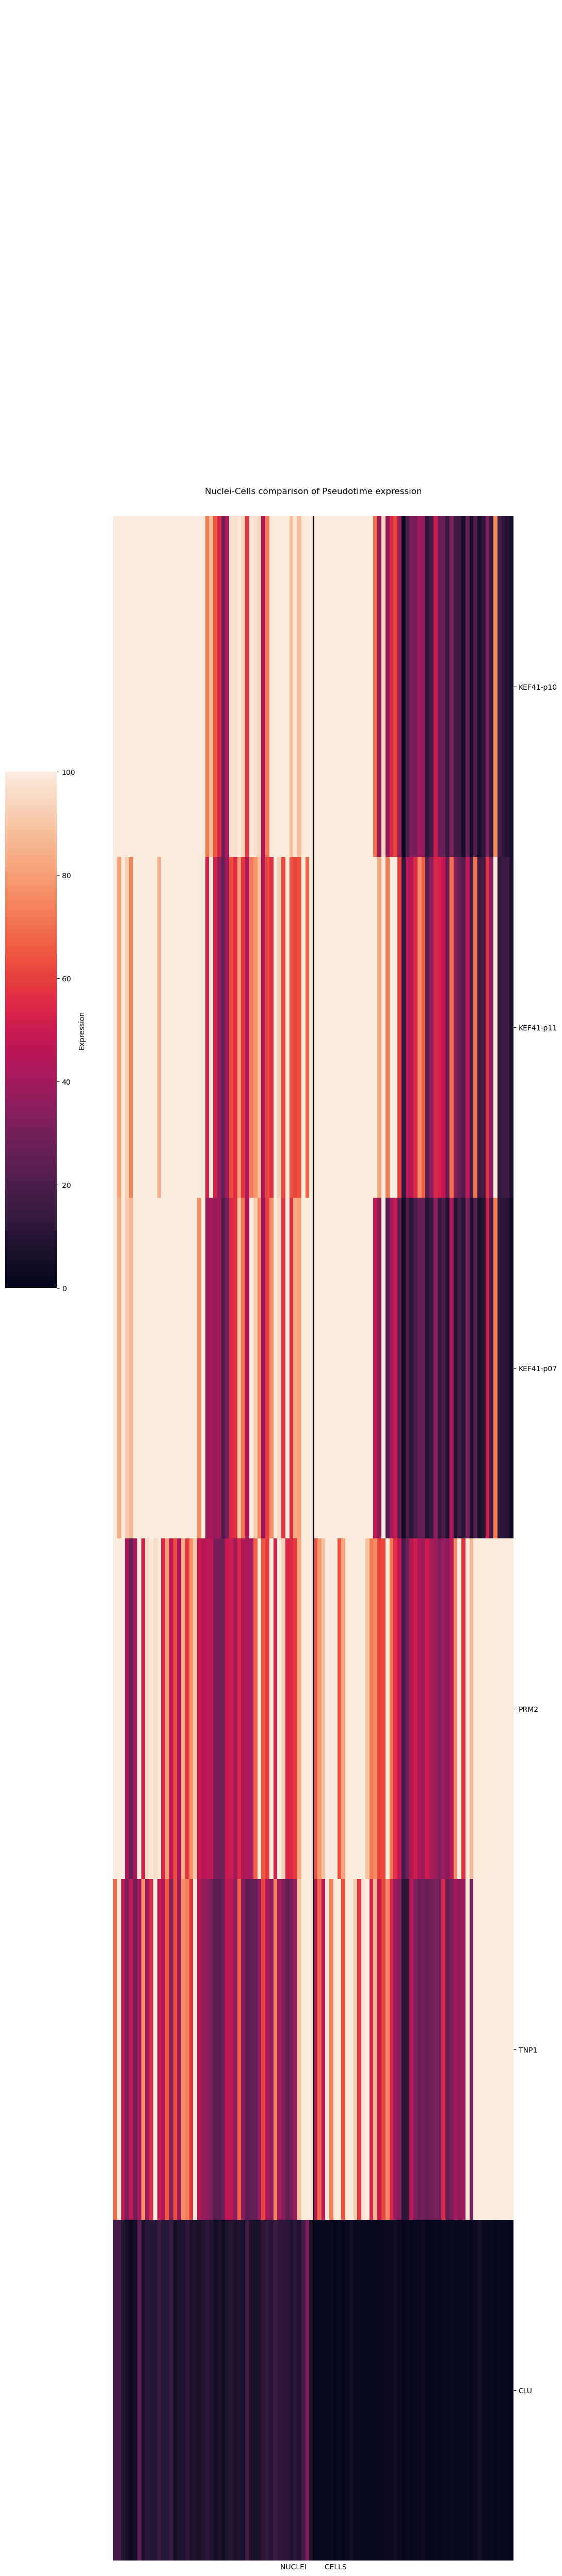

In [109]:
delay_heatmap_from_list(adata=adata_S, nuclei=NUCLEI_S, cells=CELLS_S, 
                  genes=genes, vmin=0, vmax=100, 
                  filter=False, D_th=.3, T_th=.5,
                  outname='heatmap_from_genes')